<a href="https://colab.research.google.com/github/mountaindew93/2026-1_CV/blob/main/HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
!wget "https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0309(a)(washed_out_aerial_image).tif"

--2026-04-10 12:53:44--  https://raw.githubusercontent.com/kjcheoi-class/CV/main/Fig0309(a)(washed_out_aerial_image).tif
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 589115 (575K) [image/tiff]
Saving to: ‘Fig0309(a)(washed_out_aerial_image).tif’

Fig0309(a)(washed_o 100%[===================>] 575.31K  --.-KB/s    in 0.03s   

2026-04-10 12:53:45 (19.8 MB/s) - ‘Fig0309(a)(washed_out_aerial_image).tif’ saved [589115/589115]



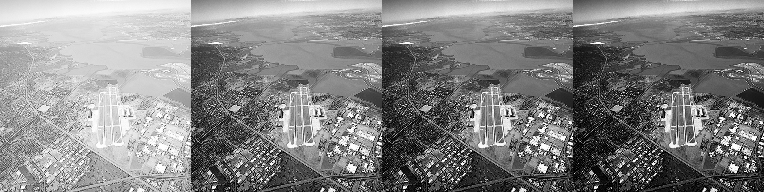

In [11]:
import cv2 as cv
import numpy as np
from google.colab.patches import cv2_imshow

img = cv.imread("Fig0309(a)(washed_out_aerial_image).tif")
img = cv.resize(img, dsize=(0,0), fx=0.25, fy=0.25) #1/4로 크기 줄이기

def gamma(f, gamma=1.0):
  f1 = f/255.0 #0~1사이로 정규화
  return np.uint8(255*(f1**gamma)) #L-1*f(i,j)^r
  #-> 다시 8비트 정수(0-255)로 (이미지 출력 함수는 정수 데이터를 취급하기 때문에)

gc = np.hstack((gamma(img, 1.0), gamma(img,3.0), gamma(img,4.0), gamma(img,5.0)))
cv2_imshow(gc)

# 변환 후 밝기 = (원래 밝기)^r
# r<1 = 그래프가 위로 볼록해지며 어두운 부분의 값 커짐 -> 밝아짐
# r>1 = 그래프가 아래로 볼록, 밝은 값들이 작아짐 -> 대비 강해짐
# 첫 사진은 너무 밝아 잘 안보이므로, r 값을 1보다 크게 주면서 전체적으로 어둡게하고 대비를 키움